#  GraphRAG with Neo4j and LangChain


### 1. Install Required Dependencies


In [ ]:
# Install modern standalone dependencies
%pip install --upgrade --quiet langchain langchain-neo4j langchain-groq langchain-google-genai neo4j python-dotenv graphviz


### 2. Load Environment Variables from `.env`
Ensure your `.env` file in the project root contains:
```env
GROQ_API_KEY="your-groq-api-key"
GEMINI_API_KEY="your-gemini-api-key"
NEO4J_URI="neo4j+s://xxxx.databases.neo4j.io"
NEO4J_USERNAME="your-username"
NEO4J_PASSWORD="your-password"
NEO4J_DATABASE="your-database"
```

In [ ]:
import os
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())

NEO4J_URI = os.getenv("NEO4J_URI")
NEO4J_USERNAME = os.getenv("NEO4J_USERNAME")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD")
NEO4J_DATABASE = os.getenv("NEO4J_DATABASE", NEO4J_USERNAME)
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")


if NEO4J_URI and NEO4J_URI.startswith("neo4j+s://"):
    NEO4J_URI_CONNECT = NEO4J_URI.replace("neo4j+s://", "neo4j+ssc://")
else:
    NEO4J_URI_CONNECT = NEO4J_URI

print(f"Neo4j URI: {NEO4J_URI_CONNECT}")
print(f"Neo4j Username: {NEO4J_USERNAME}")
print(f"Neo4j Database: {NEO4J_DATABASE}")
print(f"Groq API Key Configured: {bool(GROQ_API_KEY)}")
print(f"Gemini API Key Configured: {bool(GEMINI_API_KEY)}")

Neo4j URI: neo4j+ssc://9391cbb2.databases.neo4j.io
Neo4j Username: 9391cbb2
Neo4j Database: 9391cbb2
Groq API Key Configured: True
Gemini API Key Configured: True


### 3. Connect to Neo4j Database
Using `Neo4jGraph` from `langchain_neo4j`.

In [33]:
from langchain_neo4j import Neo4jGraph

graph = Neo4jGraph(
    url=NEO4J_URI_CONNECT,
    username=NEO4J_USERNAME,
    password=NEO4J_PASSWORD,
    database=NEO4J_DATABASE,
)
graph

### 4. Initialize LLM with Groq
Using the latest high-performance reasoning model on Groq (`openai/gpt-oss-20b` or `qwen/qwen3.8-27b`).

In [34]:
from langchain_groq import ChatGroq

# Use openai/gpt-oss-120b on Groq (fully supports tool calling and structured output without rate limit or parsing errors)
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

# Alternative: To use Google Gemini, uncomment below:
# from langchain_google_genai import ChatGoogleGenerativeAI
# llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.3', 'langchain': '1.4.0'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001FACA1D5950>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001FACA1D6350>, model_name='openai/gpt-oss-120b', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'))

### 5. Extract Knowledge Graph from Unstructured Text
Using `LLMGraphTransformer` from `langchain_neo4j` to automatically extract entities (nodes) and relations from raw text.

In [35]:
from langchain_core.documents import Document

text = """
Elon Reeve Musk (born June 28, 1971) is a businessman and investor known for his key roles in space
company SpaceX and automotive company Tesla, Inc. Other involvements include ownership of X Corp.,
formerly Twitter, and his role in the founding of The Boring Company, xAI, Neuralink and OpenAI. 
He is one of the wealthiest people in the world; as of July 2024, Forbes estimates his net worth to be 
US$221 billion. Musk was born in Pretoria to Maye and engineer Errol Musk, and briefly attended 
the University of Pretoria before immigrating to Canada at age 18, acquiring citizenship through 
his Canadian-born mother. Two years later, he matriculated at Queen's University at Kingston in Canada.
Musk later transferred to the University of Pennsylvania and received bachelor's degrees in economics
and physics. He moved to California in 1995 to attend Stanford University, but dropped out after
two days and, with his brother Kimbal, co-founded online city guide software company Zip2.
"""

documents = [Document(page_content=text.strip())]
documents

[Document(metadata={}, page_content="Elon Reeve Musk (born June 28, 1971) is a businessman and investor known for his key roles in space\ncompany SpaceX and automotive company Tesla, Inc. Other involvements include ownership of X Corp.,\nformerly Twitter, and his role in the founding of The Boring Company, xAI, Neuralink and OpenAI. \nHe is one of the wealthiest people in the world; as of July 2024, Forbes estimates his net worth to be \nUS$221 billion. Musk was born in Pretoria to Maye and engineer Errol Musk, and briefly attended \nthe University of Pretoria before immigrating to Canada at age 18, acquiring citizenship through \nhis Canadian-born mother. Two years later, he matriculated at Queen's University at Kingston in Canada.\nMusk later transferred to the University of Pennsylvania and received bachelor's degrees in economics\nand physics. He moved to California in 1995 to attend Stanford University, but dropped out after\ntwo days and, with his brother Kimbal, co-founded onlin

In [36]:
from langchain_neo4j import LLMGraphTransformer

llm_transformer = LLMGraphTransformer(llm=llm)
graph_documents = llm_transformer.convert_to_graph_documents(documents)
graph_documents

[GraphDocument(nodes=[Node(id='Elon Reeve Musk', type='Person', properties={}), Node(id='Maye', type='Person', properties={}), Node(id='Errol Musk', type='Person', properties={}), Node(id='Kimbal', type='Person', properties={}), Node(id='Spacex', type='Company', properties={}), Node(id='Tesla, Inc.', type='Company', properties={}), Node(id='X Corp.', type='Company', properties={}), Node(id='Twitter', type='Company', properties={}), Node(id='The Boring Company', type='Company', properties={}), Node(id='Xai', type='Company', properties={}), Node(id='Neuralink', type='Company', properties={}), Node(id='Openai', type='Company', properties={}), Node(id='Forbes', type='Organization', properties={}), Node(id='Pretoria', type='Place', properties={}), Node(id='Canada', type='Place', properties={}), Node(id='University Of Pretoria', type='Organization', properties={}), Node(id="Queen'S University At Kingston", type='Organization', properties={}), Node(id='University Of Pennsylvania', type='Organ

In [37]:
print("Extracted Nodes:")
for node in graph_documents[0].nodes:
    print(f" - [{node.type}] {node.id}")

print("\nExtracted Relationships:")
for rel in graph_documents[0].relationships:
    print(f" - ({rel.source.id}) -[:{rel.type}]-> ({rel.target.id})")

Extracted Nodes:
 - [Person] Elon Reeve Musk
 - [Person] Maye
 - [Person] Errol Musk
 - [Person] Kimbal
 - [Company] Spacex
 - [Company] Tesla, Inc.
 - [Company] X Corp.
 - [Company] Twitter
 - [Company] The Boring Company
 - [Company] Xai
 - [Company] Neuralink
 - [Company] Openai
 - [Organization] Forbes
 - [Place] Pretoria
 - [Place] Canada
 - [Organization] University Of Pretoria
 - [Organization] Queen'S University At Kingston
 - [Organization] University Of Pennsylvania
 - [Organization] Stanford University
 - [Company] Zip2
 - [Place] California

Extracted Relationships:
 - (Elon Reeve Musk) -[:BORN_IN]-> (Pretoria)
 - (Elon Reeve Musk) -[:CHILD_OF]-> (Maye)
 - (Elon Reeve Musk) -[:CHILD_OF]-> (Errol Musk)
 - (Elon Reeve Musk) -[:CITIZENSHIP]-> (Canada)
 - (Elon Reeve Musk) -[:ATTENDED]-> (University Of Pretoria)
 - (Elon Reeve Musk) -[:ATTENDED]-> (Queen'S University At Kingston)
 - (Elon Reeve Musk) -[:ATTENDED]-> (University Of Pennsylvania)
 - (Elon Reeve Musk) -[:ATTENDED]-

### 5.1 Visualize Extracted Knowledge Graph with Graphviz
Render the extracted nodes and relationships as an interactive visual diagram.

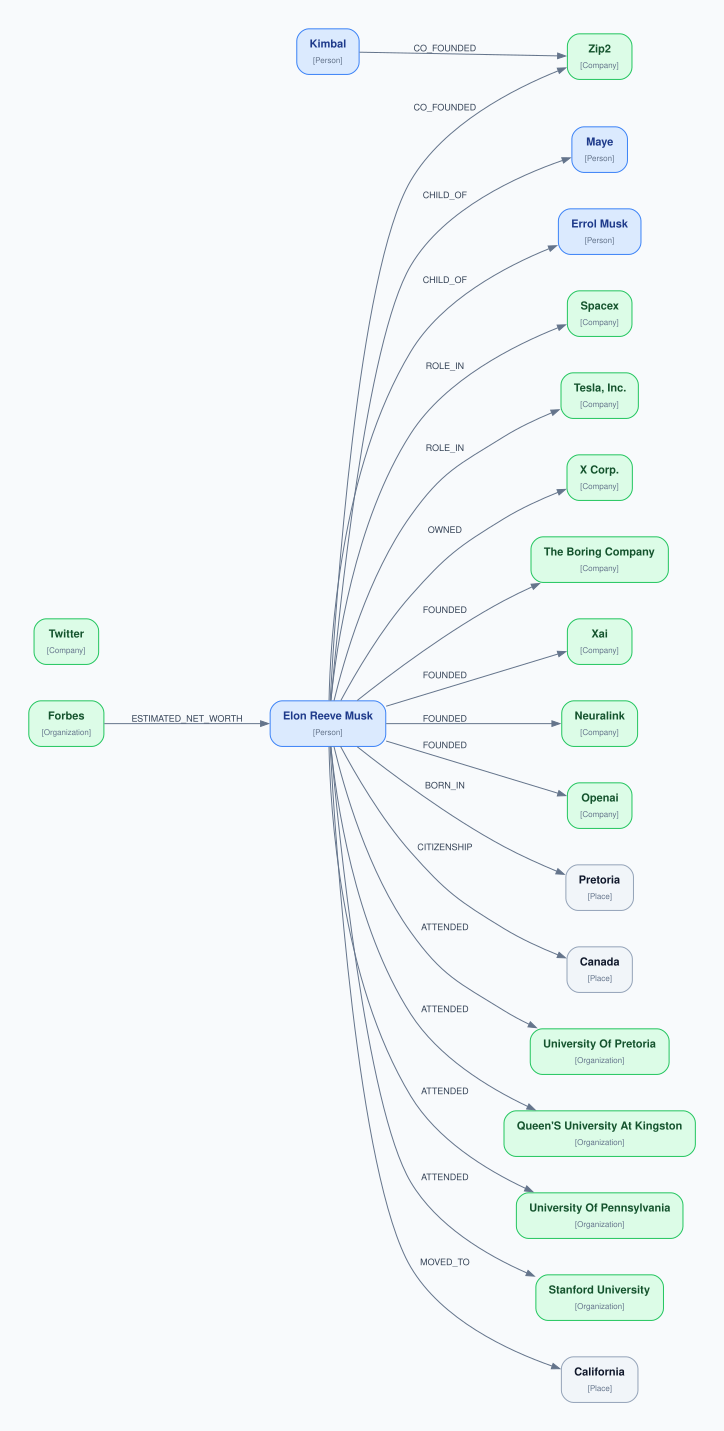

In [38]:
import os
import graphviz

# Ensure Graphviz binary path is available in PATH
graphviz_paths = [
    r"C:\Users\SPAR-HYD-049\AppData\Local\Programs\Graphviz\Graphviz-16.1.0-win64\bin",
    r"C:\Program Files\Graphviz\bin",
]
for p in graphviz_paths:
    if os.path.exists(p) and p not in os.environ.get("PATH", ""):
        os.environ["PATH"] = p + os.pathsep + os.environ.get("PATH", "")

def visualize_knowledge_graph(graph_doc, title="Knowledge Graph"):
    """
    Renders a LangChain GraphDocument into an aesthetically styled Graphviz diagram.
    """
    dot = graphviz.Digraph(
        name=title,
        comment=title,
        graph_attr={
            "rankdir": "LR",
            "bgcolor": "#F8FAFC",
            "fontsize": "13",
            "fontname": "Helvetica",
            "pad": "0.4",
            "nodesep": "0.5",
            "ranksep": "0.7",
        },
        node_attr={
            "shape": "box",
            "style": "rounded,filled",
            "fontname": "Helvetica",
            "fontsize": "11",
            "margin": "0.15,0.1",
        },
        edge_attr={
            "fontname": "Helvetica",
            "fontsize": "9",
            "color": "#64748B",
            "fontcolor": "#334155",
            "arrowsize": "0.8",
        }
    )

    # Modern theme color palette per node type
    type_styles = {
        "Person": {"fill": "#DBEAFE", "border": "#3B82F6", "font": "#1E3A8A"},
        "Organization": {"fill": "#DCFCE7", "border": "#22C55E", "font": "#14532D"},
        "Company": {"fill": "#DCFCE7", "border": "#22C55E", "font": "#14532D"},
        "Location": {"fill": "#FEF3C7", "border": "#F59E0B", "font": "#78350F"},
        "Event": {"fill": "#FCE7F3", "border": "#EC4899", "font": "#831843"},
        "Concept": {"fill": "#EDE9FE", "border": "#8B5CF6", "font": "#4C1D95"},
        "default": {"fill": "#F1F5F9", "border": "#94A3B8", "font": "#0F172A"}
    }

    # Add nodes with custom HTML-like formatting
    for node in graph_doc.nodes:
        style = type_styles.get(node.type, type_styles["default"])
        html_label = (
            f'<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0">'
            f'<TR><TD><B>{node.id}</B></TD></TR>'
            f'<TR><TD><FONT POINT-SIZE="8" COLOR="#64748B">[{node.type}]</FONT></TD></TR>'
            f'</TABLE>>'
        )
        dot.node(
            node.id,
            label=html_label,
            fillcolor=style["fill"],
            color=style["border"],
            fontcolor=style["font"],
        )

    # Add relationships
    for rel in graph_doc.relationships:
        dot.edge(rel.source.id, rel.target.id, label=f" {rel.type} ")

    return dot

# Render the extracted Knowledge Graph from step 5
kg_diagram = visualize_knowledge_graph(graph_documents[0], title="Elon Musk Knowledge Graph")
kg_diagram


### 6. Ingest Movie Dataset into Neo4j
Load sample movie data into the graph using Cypher `MERGE` statements.

In [39]:
movie_query = """
LOAD CSV WITH HEADERS FROM
'https://raw.githubusercontent.com/tomasonjo/blog-datasets/main/movies/movies_small.csv' as row

MERGE(m:Movie{id:row.movieId})
SET m.released = date(row.released),
    m.title = row.title,
    m.imdbRating = toFloat(row.imdbRating)
FOREACH (director in split(row.director, '|') |
    MERGE (p:Person {name:trim(director)})
    MERGE (p)-[:DIRECTED]->(m))
FOREACH (actor in split(row.actors, '|') |
    MERGE (p:Person {name:trim(actor)})
    MERGE (p)-[:ACTED_IN]->(m))
FOREACH (genre in split(row.genres, '|') |
    MERGE (g:Genre {name:trim(genre)})
    MERGE (m)-[:IN_GENRE]->(g))
"""

graph.query(movie_query)

[]

In [40]:
graph.refresh_schema()
print(graph.schema)

Node properties:
Movie {id: STRING, released: DATE, title: STRING, imdbRating: FLOAT}
Person {name: STRING}
Genre {name: STRING}
Relationship properties:

The relationships:
(:Movie)-[:IN_GENRE]->(:Genre)
(:Person)-[:DIRECTED]->(:Movie)
(:Person)-[:ACTED_IN]->(:Movie)


### 6.1 Visualize Movie Dataset Subgraph with Graphviz
Query and visualize a sample movie subgraph from Neo4j showing movies, their directors, actors, and genres.

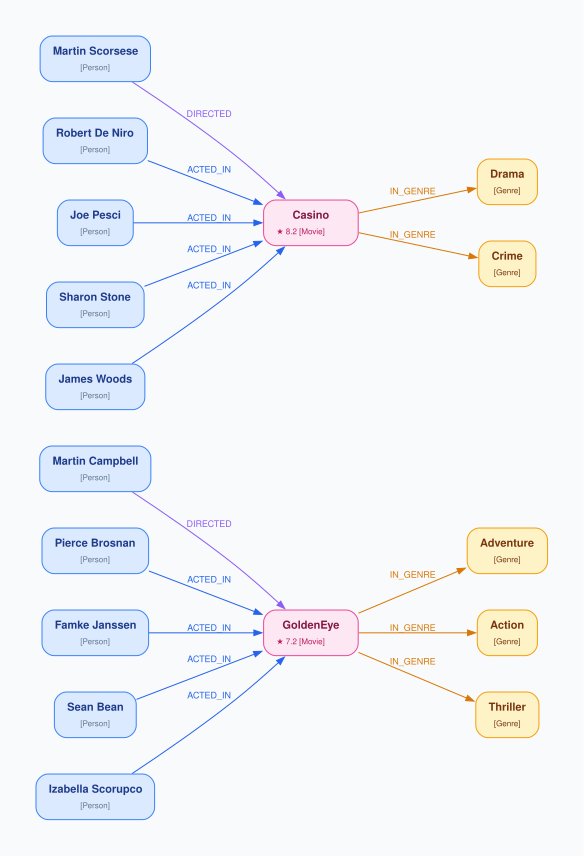

In [41]:
def visualize_movie_subgraph(graph, movie_titles=["GoldenEye", "Casino"]):
    """
    Queries Neo4j for specified movies, their actors, directors, and genres,
    and returns a styled Graphviz visual diagram.
    """
    cypher = """
    MATCH (m:Movie)
    WHERE m.title IN $titles
    OPTIONAL MATCH (p:Person)-[r:ACTED_IN|DIRECTED]->(m)
    OPTIONAL MATCH (m)-[:IN_GENRE]->(g:Genre)
    RETURN m.title AS movie, m.imdbRating AS rating,
           p.name AS person, type(r) AS rel,
           g.name AS genre
    """
    records = graph.query(cypher, params={"titles": movie_titles})

    dot = graphviz.Digraph(
        name="Movie Subgraph",
        comment="Movie Subgraph",
        graph_attr={
            "rankdir": "LR",
            "bgcolor": "#F8FAFC",
            "fontsize": "13",
            "fontname": "Helvetica",
            "pad": "0.5",
            "nodesep": "0.5",
            "ranksep": "0.8",
        },
        node_attr={
            "shape": "box",
            "style": "rounded,filled",
            "fontname": "Helvetica",
            "fontsize": "11",
            "margin": "0.15,0.1",
        },
        edge_attr={
            "fontname": "Helvetica",
            "fontsize": "9",
            "arrowsize": "0.8",
        }
    )

    movies_added = set()
    people_added = set()
    genres_added = set()
    edges_added = set()

    for row in records:
        movie = row.get("movie")
        rating = row.get("rating")
        person = row.get("person")
        rel = row.get("rel")
        genre = row.get("genre")

        # Movie Node (Rose badge with rating)
        if movie and movie not in movies_added:
            movies_added.add(movie)
            rating_str = f"★ {rating}" if rating else ""
            movie_label = (
                f'<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0">'
                f'<TR><TD><B>{movie}</B></TD></TR>'
                f'<TR><TD><FONT POINT-SIZE="8" COLOR="#BE185D">{rating_str} [Movie]</FONT></TD></TR>'
                f'</TABLE>>'
            )
            dot.node(
                f"m_{movie}",
                label=movie_label,
                fillcolor="#FCE7F3",
                color="#EC4899",
                fontcolor="#831843",
            )

        # Person Node (Blue badge) and Relationship
        if person and rel and movie:
            if person not in people_added:
                people_added.add(person)
                person_label = (
                    f'<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0">'
                    f'<TR><TD><B>{person}</B></TD></TR>'
                    f'<TR><TD><FONT POINT-SIZE="8" COLOR="#64748B">[Person]</FONT></TD></TR>'
                    f'</TABLE>>'
                )
                dot.node(
                    f"p_{person}",
                    label=person_label,
                    fillcolor="#DBEAFE",
                    color="#3B82F6",
                    fontcolor="#1E3A8A",
                )
            edge_key = (f"p_{person}", f"m_{movie}", rel)
            if edge_key not in edges_added:
                edges_added.add(edge_key)
                edge_color = "#8B5CF6" if rel == "DIRECTED" else "#2563EB"
                dot.edge(
                    f"p_{person}",
                    f"m_{movie}",
                    label=f" {rel} ",
                    color=edge_color,
                    fontcolor=edge_color,
                )

        # Genre Node (Amber badge) and Relationship
        if genre and movie:
            if genre not in genres_added:
                genres_added.add(genre)
                genre_label = (
                    f'<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0">'
                    f'<TR><TD><B>{genre}</B></TD></TR>'
                    f'<TR><TD><FONT POINT-SIZE="8" COLOR="#78350F">[Genre]</FONT></TD></TR>'
                    f'</TABLE>>'
                )
                dot.node(
                    f"g_{genre}",
                    label=genre_label,
                    fillcolor="#FEF3C7",
                    color="#F59E0B",
                    fontcolor="#78350F",
                )
            edge_key = (f"m_{movie}", f"g_{genre}", "IN_GENRE")
            if edge_key not in edges_added:
                edges_added.add(edge_key)
                dot.edge(
                    f"m_{movie}",
                    f"g_{genre}",
                    label=" IN_GENRE ",
                    color="#D97706",
                    fontcolor="#D97706",
                )

    return dot

# Render movie subgraph for GoldenEye and Casino
movie_diagram = visualize_movie_subgraph(graph, ["GoldenEye", "Casino"])
movie_diagram


### 7. Natural Language Question Answering over Graph (`GraphCypherQAChain`)
`GraphCypherQAChain` generates Cypher queries from user questions, queries Neo4j, and returns natural language answers.
*Note: In modern LangChain, `allow_dangerous_requests=True` is required to allow execution of generated Cypher queries.*

In [42]:
from langchain_neo4j import GraphCypherQAChain

chain = GraphCypherQAChain.from_llm(
    llm=llm,
    graph=graph,
    verbose=True,
    allow_dangerous_requests=True
)
chain

GraphCypherQAChain(verbose=True, graph=<langchain_neo4j.graphs.neo4j_graph.Neo4jGraph object at 0x000001FACA1074D0>, cypher_generation_chain=PromptTemplate(input_variables=['examples', 'question', 'schema'], input_types={}, partial_variables={}, template='Task:Generate Cypher statement to query a graph database.\nInstructions:\nUse only the provided relationship types and properties in the schema.\nDo not use any other relationship types or properties that are not provided.\nSchema:\n{schema}\nNote: Do not include any explanations or apologies in your responses.\nDo not respond to any questions that might ask anything else than for you to construct a Cypher statement.\nDo not include any text except the generated Cypher statement.\n\nExamples (optional):\n{examples}\n\nThe question is:\n{question}')
| _ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.3', 'langchain': '1.4.0'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated'

In [43]:
response = chain.invoke({"query": "Who was the director of the movie GoldenEye"})
response



> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (p:Person)-[:DIRECTED]->(m:Movie {title: 'GoldenEye'})
RETURN p.name
Full Context:
[{'p.name': 'Martin Campbell'}]

> Finished chain.


{'query': 'Who was the director of the movie GoldenEye',
 'result': 'Martin Campbell was the director of the movie GoldenEye.'}

In [44]:
response = chain.invoke({"query": "tell me the genre of the movie GoldenEye"})
response



> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (m:Movie {title: "GoldenEye"})-[:IN_GENRE]->(g:Genre)
RETURN g.name AS genre
Full Context:
[{'genre': 'Adventure'}, {'genre': 'Action'}, {'genre': 'Thriller'}]

> Finished chain.


{'query': 'tell me the genre of the movie GoldenEye',
 'result': 'Adventure, Action, Thriller are the genres of the movie GoldenEye.'}

In [45]:
response = chain.invoke({"query": "Who was the director in movie Casino"})
response



> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (p:Person)-[:DIRECTED]->(m:Movie {title: "Casino"})
RETURN p.name
Full Context:
[{'p.name': 'Martin Scorsese'}]

> Finished chain.


{'query': 'Who was the director in movie Casino', 'result': 'Martin Scorsese.'}

In [46]:
response = chain.invoke({"query": "Which movie were released in 2008"})
response



> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (m:Movie) WHERE m.released.year = 2008 RETURN m.title
Full Context:
[]

> Finished chain.


{'query': 'Which movie were released in 2008',
 'result': "I don't know the answer."}

In [47]:
response = chain.invoke({"query": "Give me the list of movie having imdb rating more than 8"})
response



> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (m:Movie)
WHERE m.imdbRating > 8
RETURN m.title, m.imdbRating, m.released, m.id
Full Context:
[{'m.title': 'Toy Story', 'm.imdbRating': 8.3, 'm.released': neo4j.time.Date(1995, 11, 22), 'm.id': '1'}, {'m.title': 'Heat', 'm.imdbRating': 8.2, 'm.released': neo4j.time.Date(1995, 12, 15), 'm.id': '6'}, {'m.title': 'Casino', 'm.imdbRating': 8.2, 'm.released': neo4j.time.Date(1995, 11, 22), 'm.id': '16'}, {'m.title': 'Twelve Monkeys (a.k.a. 12 Monkeys)', 'm.imdbRating': 8.1, 'm.released': neo4j.time.Date(1996, 1, 5), 'm.id': '32'}, {'m.title': 'Seven (a.k.a. Se7en)', 'm.imdbRating': 8.6, 'm.released': neo4j.time.Date(1995, 9, 22), 'm.id': '47'}, {'m.title': 'Usual Suspects, The', 'm.imdbRating': 8.6, 'm.released': neo4j.time.Date(1995, 9, 15), 'm.id': '50'}, {'m.title': 'Hate (Haine, La)', 'm.imdbRating': 8.1, 'm.released': neo4j.time.Date(1996, 2, 23), 'm.id': '97'}, {'m.title': 'Braveheart', 'm.imdbRating': 8.4, 'm.releas

{'query': 'Give me the list of movie having imdb rating more than 8',
 'result': 'Toy Story, Heat, Casino, Twelve Monkeys (a.k.a. 12 Monkeys), Seven (a.k.a. Se7en), Usual Suspects, The, Hate (Haine, La), Braveheart, Taxi Driver, Anne Frank Remembered.'}

### 8. Enhancing Cypher Generation with Few-Shot Prompting
Providing example pairs of questions and Cypher queries helps the LLM generate much more accurate queries for complex patterns.

In [48]:
from langchain_core.prompts import PromptTemplate, FewShotPromptTemplate

# Note: In FewShotPromptTemplate, internal curly braces in Cypher queries must be escaped as {{...}}
# so that Python format strings do not interpret them as template parameters.
examples = [
    {
        "question": "How many artists are there?",
        "query": "MATCH (a:Person)-[:ACTED_IN]->(:Movie) RETURN count(DISTINCT a)",
    },
    {
        "question": "Which actors played in the movie Casino?",
        "query": "MATCH (m:Movie {{title: 'Casino'}})<-[:ACTED_IN]-(a) RETURN a.name",
    },
    {
        "question": "How many movies has Tom Hanks acted in?",
        "query": "MATCH (a:Person {{name: 'Tom Hanks'}})-[:ACTED_IN]->(m:Movie) RETURN count(m)",
    },
    {
        "question": "List all the genres of the movie Schindler's List",
        "query": "MATCH (m:Movie {{title: 'Schindler\\'s List'}})-[:IN_GENRE]->(g:Genre) RETURN g.name",
    },
    {
        "question": "Which actors have worked in movies from both the comedy and action genres?",
        "query": "MATCH (a:Person)-[:ACTED_IN]->(:Movie)-[:IN_GENRE]->(g1:Genre), (a)-[:ACTED_IN]->(:Movie)-[:IN_GENRE]->(g2:Genre) WHERE g1.name = 'Comedy' AND g2.name = 'Action' RETURN DISTINCT a.name",
    },
    {
        "question": "Which directors have made movies with at least three different actors named 'John'?",
        "query": "MATCH (d:Person)-[:DIRECTED]->(m:Movie)<-[:ACTED_IN]-(a:Person) WHERE a.name STARTS WITH 'John' WITH d, COUNT(DISTINCT a) AS JohnsCount WHERE JohnsCount >= 3 RETURN d.name",
    },
    {
        "question": "Identify movies where directors also played a role in the film.",
        "query": "MATCH (p:Person)-[:DIRECTED]->(m:Movie), (p)-[:ACTED_IN]->(m) RETURN m.title, p.name",
    },
    {
        "question": "Find the actor with the highest number of movies in the database.",
        "query": "MATCH (a:Actor)-[:ACTED_IN]->(:Movie) RETURN a.name, COUNT(m) AS movieCount ORDER BY movieCount DESC LIMIT 1",
    },
]

example_prompt = PromptTemplate(
    input_variables=["question", "query"],
    template="User question: {question}\nCypher query: {query}",
)

few_shot_prompt = FewShotPromptTemplate(
    examples=examples,
    example_prompt=example_prompt,
    prefix="""Task: Generate Cypher statement to query a graph database.
Instructions:
Use only the provided relationship types and properties in the schema.
Do not use any other relationship types or properties that are not provided.
Schema:
{schema}

Examples:""",
    suffix="""User question: {question}
Cypher query:""",
    input_variables=["question", "schema"],
)

few_shot_chain = GraphCypherQAChain.from_llm(
    llm=llm,
    graph=graph,
    cypher_prompt=few_shot_prompt,
    verbose=True,
    allow_dangerous_requests=True
)

response = few_shot_chain.invoke({"query": "How many artists are there?"})
response



> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (a:Person)-[:ACTED_IN]->(:Movie)
RETURN count(DISTINCT a) AS artistCount
Full Context:
[{'artistCount': 967}]

> Finished chain.


{'query': 'How many artists are there?', 'result': 'There are 967 artists.'}